# SISTEM CERDAS - TUGAS BESAR PEMROGRAMAN

**Analisis Klasifikasi Jenis Padi Menggunakan Machine Learning**

Nama : Aldi Firmansyah
Kelas: IT-47-03


## 1. PENDAHULUAN DAN PEMAPARAN DATA

### 1.1 Deskripsi Masalah

Tugas ini bertujuan untuk mengembangkan sistem klasifikasi jenis padi otomatis menggunakan machine learning. Masalah yang ingin diselesaikan adalah mengklasifikasikan jenis padi berdasarkan parameter fisik biji padi, seperti Area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, dan AspectRation. Sistem ini akan membantu dalam mengenali dan mengklasifikasikan padi berdasarkan fitur-fitur tersebut untuk berbagai tujuan pertanian.

### 1.2 Dataset dan Sumber Data

Dataset yang digunakan adalah Rice Classification Dataset, yang berisi informasi terkait ukuran dan bentuk biji padi untuk prediksi jenis padi. Data ini mencakup parameter seperti Area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, serta Class sebagai label target untuk jenis padi. Dataset ini digunakan untuk membangun model klasifikasi berbasis machine learning.

[Link Dataset](https://www.kaggle.com/datasets/mssmartypants/rice-type-classification)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel

In [ ]:
data = pd.read_csv('riceClassification.csv')
data.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [ ]:
data.shape

(18185, 12)

In [ ]:
data.sample(3)

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
485,486,6073,138.571715,56.462442,0.913223,6361,87.933974,0.573791,359.911,0.589146,2.454228,1
11954,11955,8696,154.483517,72.604606,0.882676,8914,105.224004,0.631793,371.770,0.790644,2.127737,0
13608,13609,8009,150.584545,68.833531,0.889411,8233,100.982055,0.668978,361.018,0.772201,2.187663,0


In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18185 entries, 0 to 18184
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               18185 non-null  int64  
 1   Area             18185 non-null  int64  
 2   MajorAxisLength  18185 non-null  float64
 3   MinorAxisLength  18185 non-null  float64
 4   Eccentricity     18185 non-null  float64
 5   ConvexArea       18185 non-null  int64  
 6   EquivDiameter    18185 non-null  float64
 7   Extent           18185 non-null  float64
 8   Perimeter        18185 non-null  float64
 9   Roundness        18185 non-null  float64
 10  AspectRation     18185 non-null  float64
 11  Class            18185 non-null  int64  
dtypes: float64(8), int64(4)
memory usage: 1.7 MB


,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
count,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000
mean,9093.000000,7036.492989,151.680754,59.807851,0.915406,7225.817872,94.132952,0.616653,351.606949,0.707998,2.599081,0.549079
std,5249.701658,1467.197150,12.376402,10.061653,0.030575,1502.006571,9.906250,0.104389,29.500620,0.067310,0.434836,0.497599
min,1.000000,2522.000000,74.133114,34.409894,0.676647,2579.000000,56.666658,0.383239,197.015000,0.174590,1.358128,0.000000
25%,4547.000000,5962.000000,145.675910,51.393151,0.891617,6125.000000,87.126656,0.538530,333.990000,0.650962,2.208527,0.000000
50%,9093.000000,6660.000000,153.883750,55.724288,0.923259,6843.000000,92.085696,0.601194,353.088000,0.701941,2.602966,1.000000
75%,13639.000000,8423.000000,160.056214,70.156593,0.941372,8645.000000,103.559146,0.695664,373.003000,0.769280,2.964101,1.000000
max,18185.000000,10210.000000,183.211434,82.550762,0.966774,11008.000000,114.016559,0.886573,508.511000,0.904748,3.911845,1.000000


In [ ]:
data.isnull().sum()

,0
id,0
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Perimeter,0
Roundness,0


### 1.3 Exploratory Data Analysis (EDA)

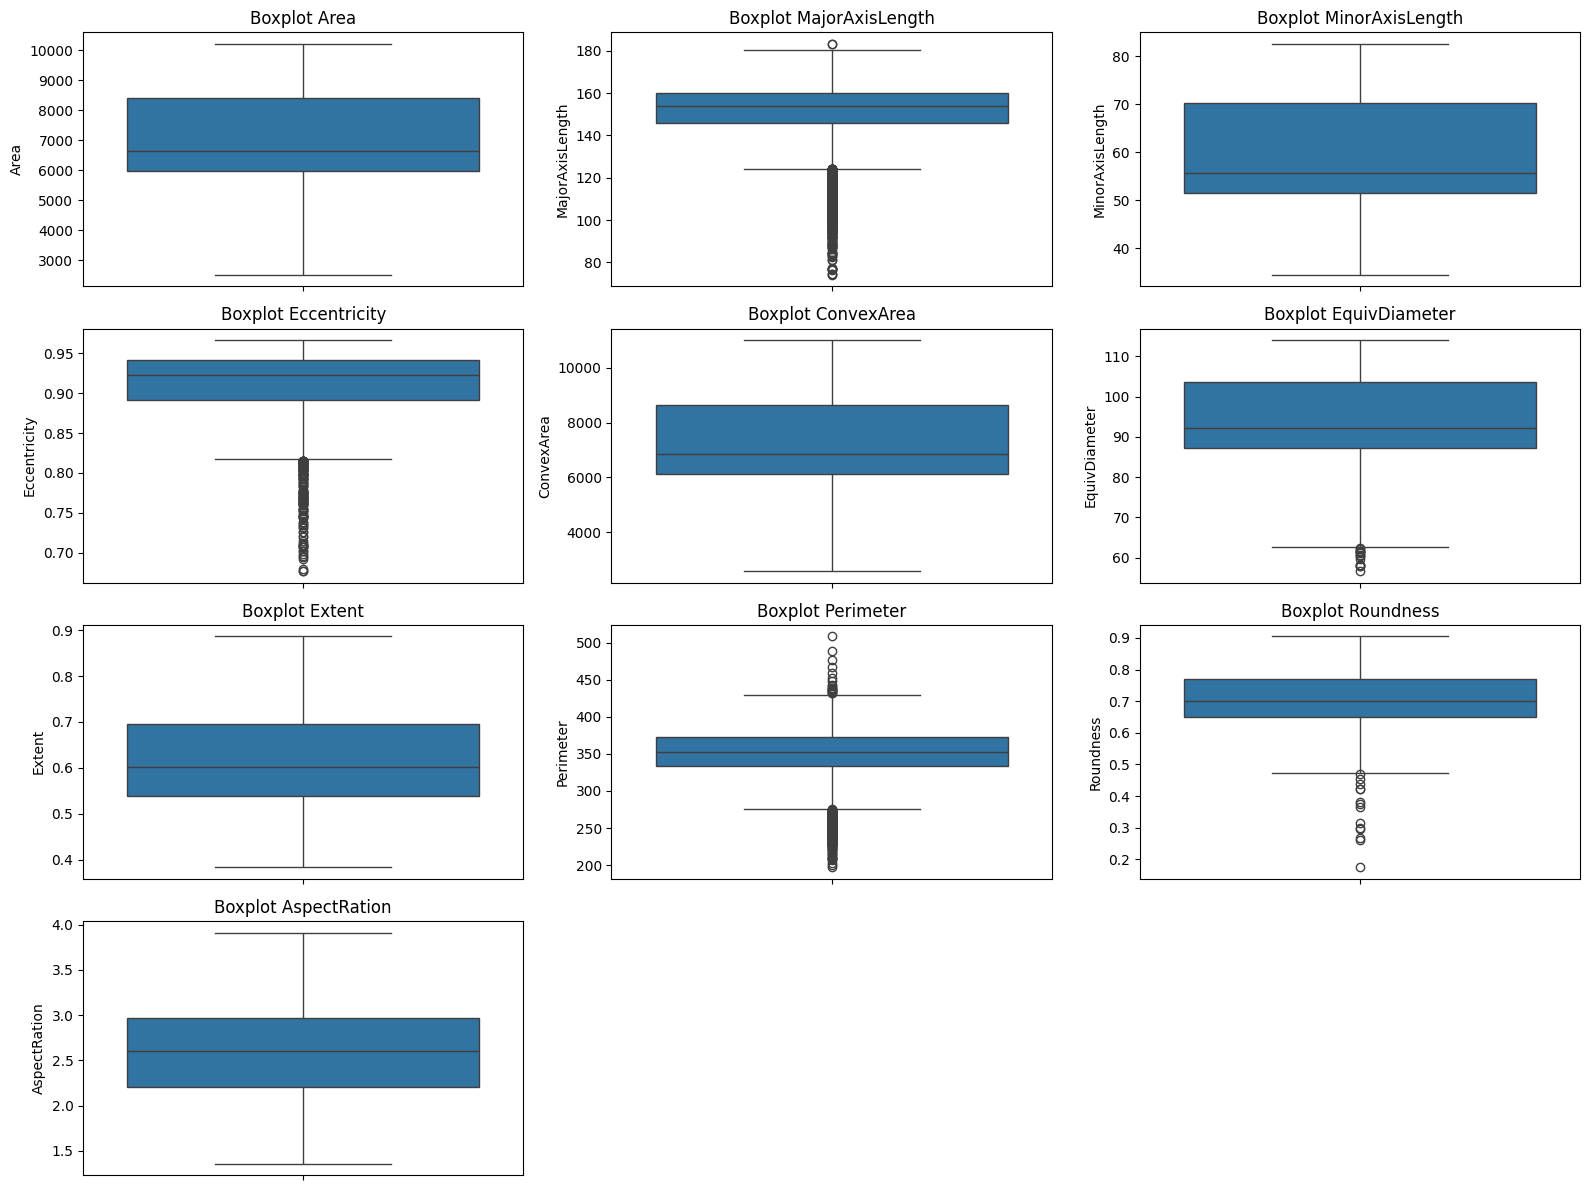

In [ ]:
data.columns = data.columns.str.strip()

plt.figure(figsize=(16, 12))
numeric_cols = ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
                'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter',
                'Roundness', 'AspectRation']

for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i+1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot {col}', fontsize=12)
    plt.ylabel(col, fontsize=10)

plt.tight_layout()
plt.savefig('boxplot_fitur_rice.png')
plt.show()

### 1.4 Pre-processing Dataset
#### 1.4.1 Penanganan Outliers

In [ ]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    outliers_removed = 0

    for column in columns:
        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_count = len(df_clean[(df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)])
        outliers_removed += outliers_count
        print(f"Outliers di kolom {column}: {outliers_count} data")

        df_clean = df_clean[(df_clean[column] >= lower_bound) & (df_clean[column] <= upper_bound)]

    print(f"\nTotal outliers yang dihapus: {outliers_removed}")
    print(f"Data tersisa: {len(df_clean)} dari {len(df)} data asli")

    return df_clean

In [ ]:
numeric_columns = data.select_dtypes(include=[np.number]).columns.tolist()
data_clean = remove_outliers_iqr(data, numeric_columns)
data = data_clean.copy()

Outliers di kolom id: 0 data
Outliers di kolom Area: 0 data
Outliers di kolom MajorAxisLength: 538 data
Outliers di kolom MinorAxisLength: 0 data
Outliers di kolom Eccentricity: 16 data
Outliers di kolom ConvexArea: 0 data
Outliers di kolom EquivDiameter: 0 data
Outliers di kolom Extent: 0 data
Outliers di kolom Perimeter: 29 data
Outliers di kolom Roundness: 5 data
Outliers di kolom AspectRation: 0 data
Outliers di kolom Class: 0 data

Total outliers yang dihapus: 588
Data tersisa: 17597 dari 18185 data asli


#### 1.4.2 Analisis Distribusi Target Variable

In [ ]:
print("\nDistribusi Target Variable (Class):")
quality_distribution = data['Class'].value_counts()
print(quality_distribution)
print(f"\nJumlah data Keseluruhan: {len(data)}")

for category in quality_distribution.index:
    percentage = quality_distribution[category] / len(data) * 100
    print(f"Persentase kelas {category}: {percentage:.2f}%")


Distribusi Target Variable (Class):
Class
1    9542
0    8055
Name: count, dtype: int64

Jumlah data Keseluruhan: 17597
Persentase kelas 1: 54.23%
Persentase kelas 0: 45.77%


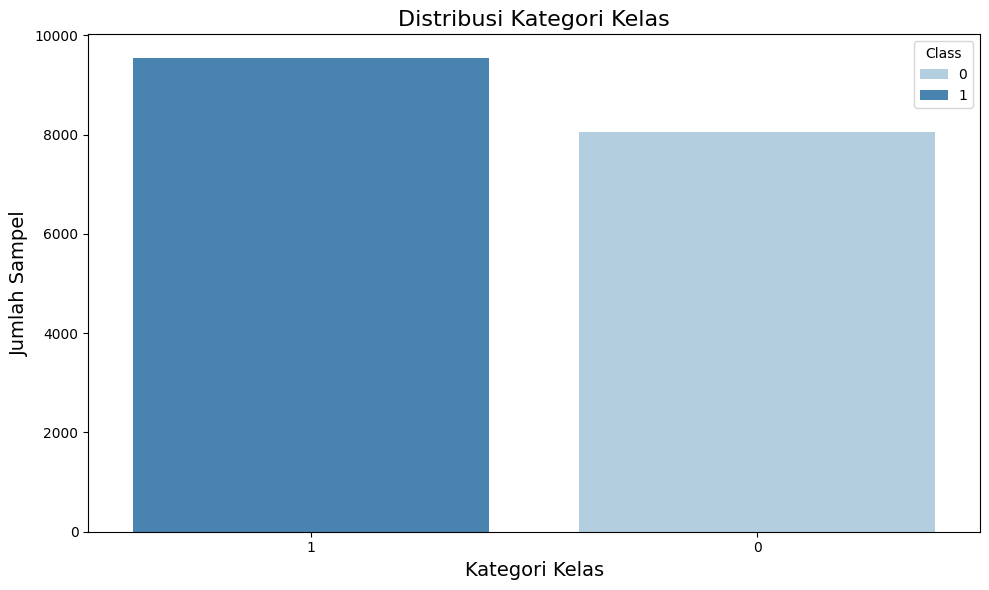

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Class', data=data, hue='Class', palette='Blues', order=quality_distribution.index)
plt.title('Distribusi Kategori Kelas', fontsize=16)
plt.xlabel('Kategori Kelas', fontsize=14)
plt.ylabel('Jumlah Sampel', fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('distribusi_kelas.png')
plt.show()

#### 1.4.3 Analisis Distribusi Fitur Numerik

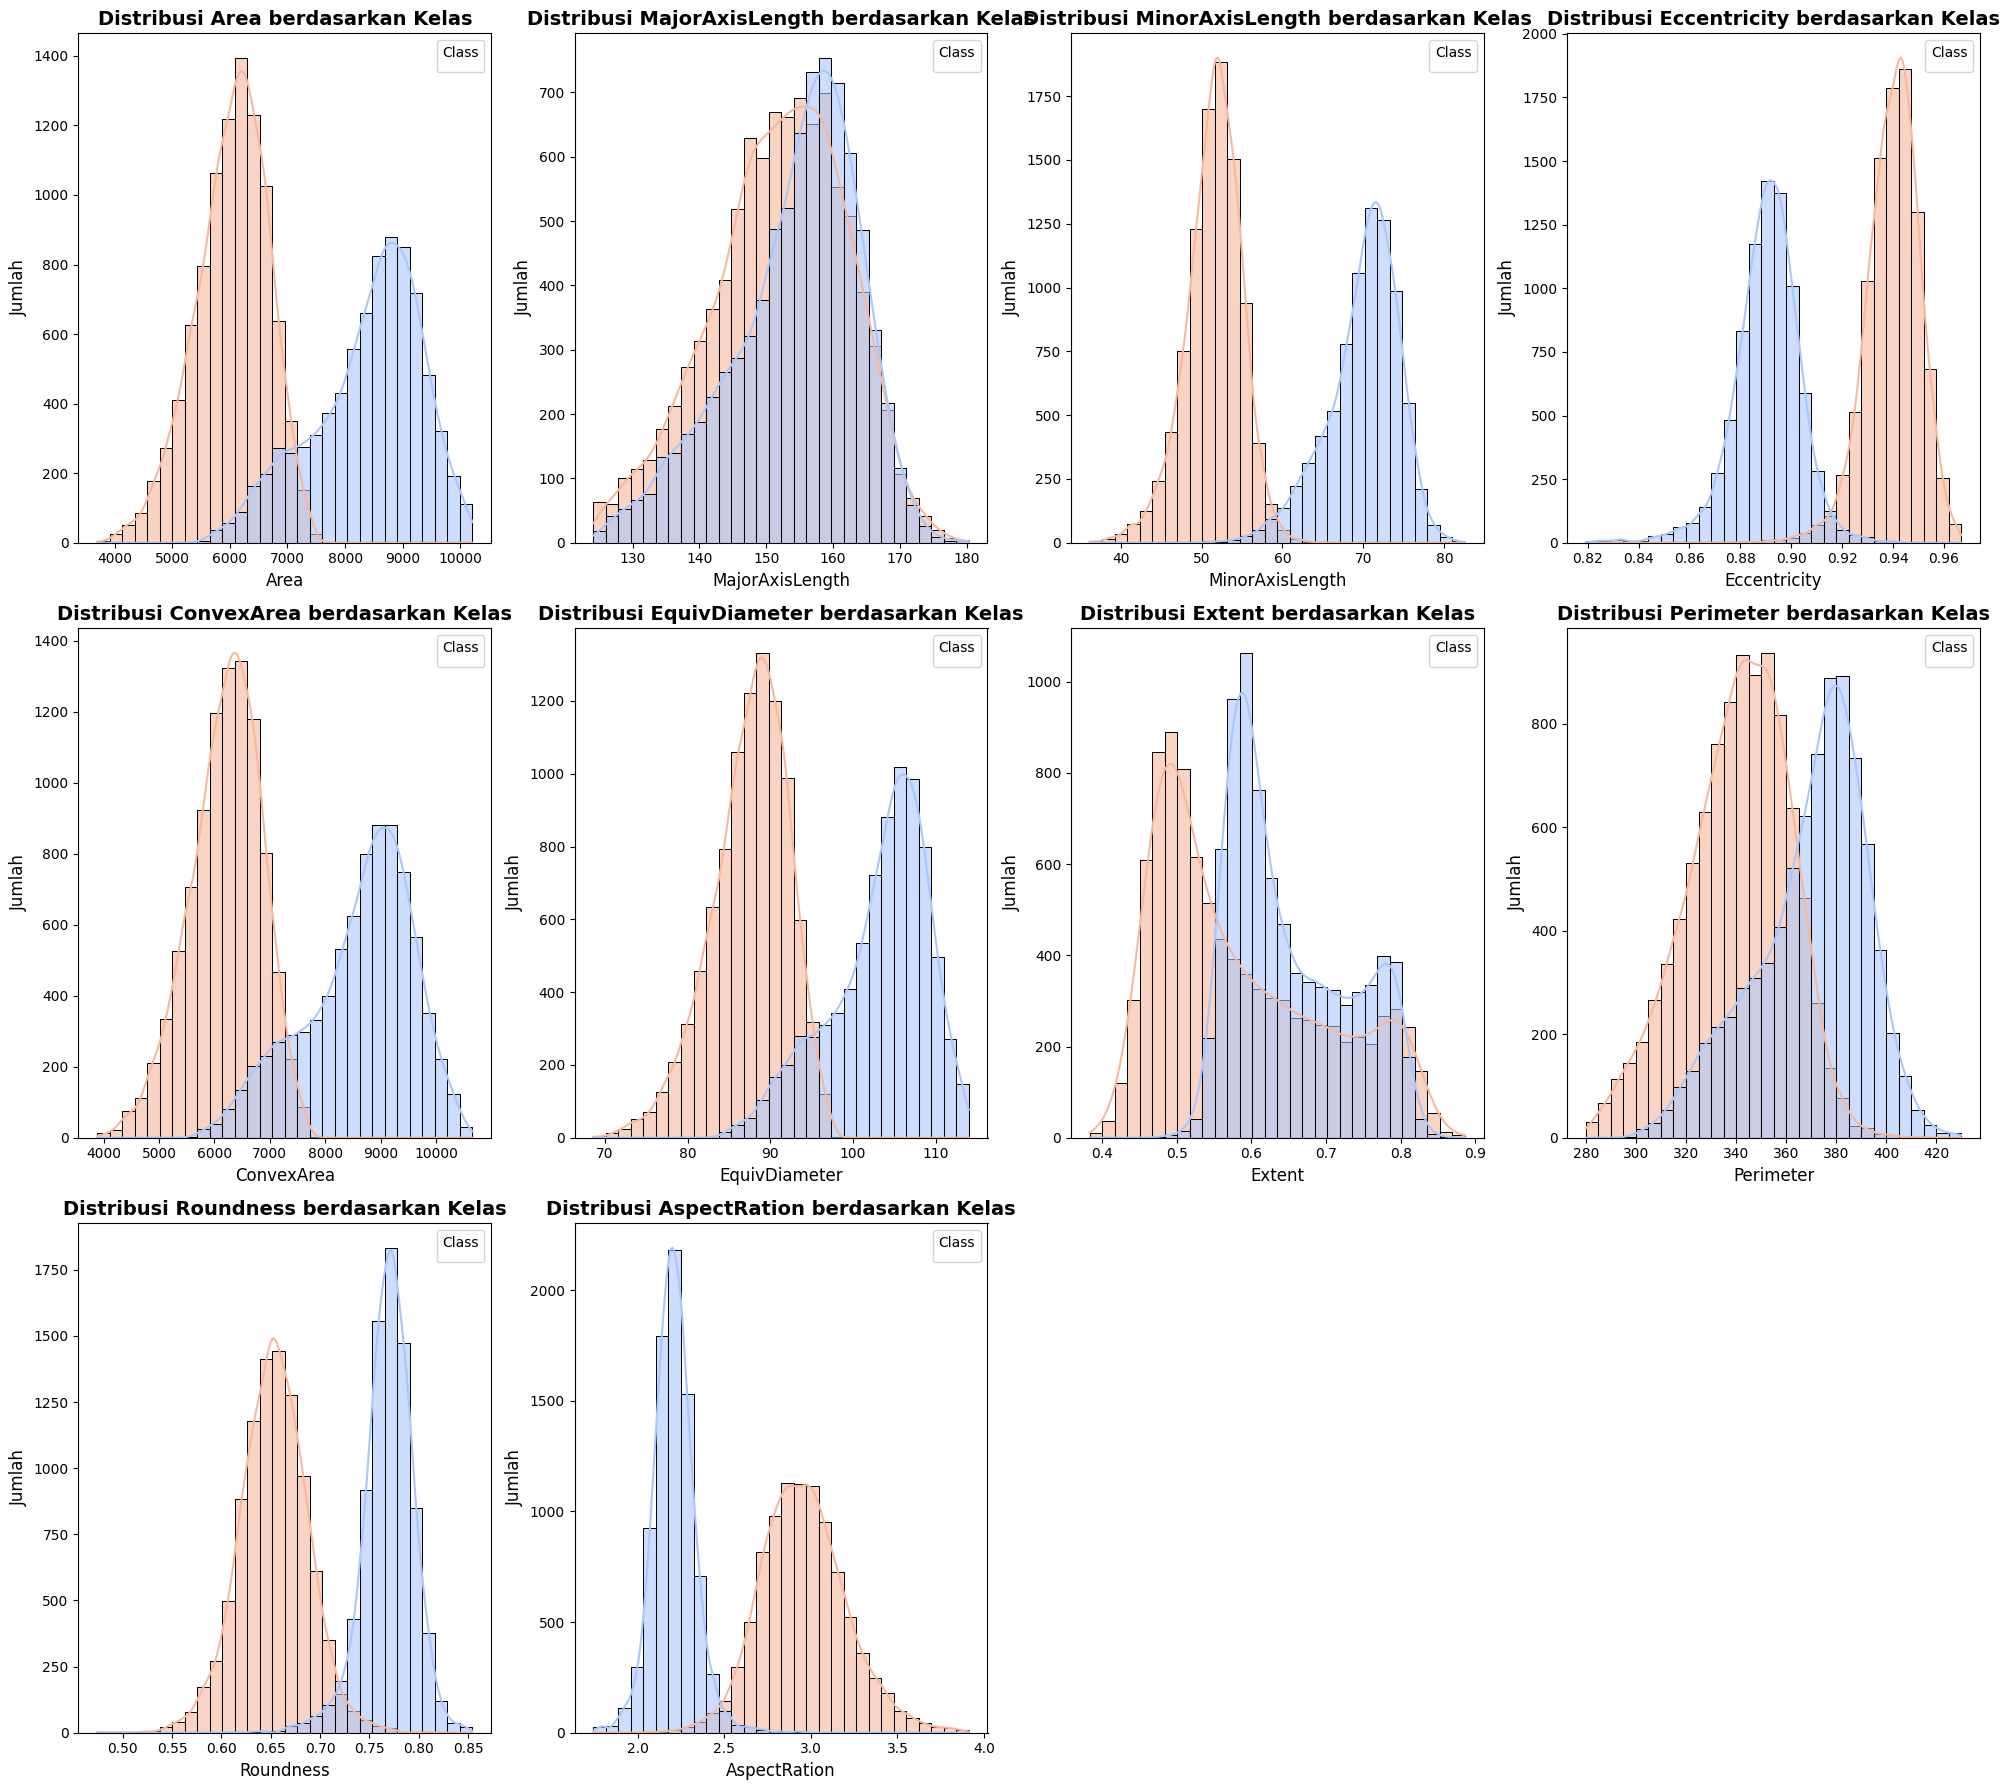

In [ ]:
plt.figure(figsize=(20, 18))

numerical_features = ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea',
                      'EquivDiameter', 'Extent', 'Perimeter', 'Roundness', 'AspectRation']

for i, column in enumerate(numerical_features):
    plt.subplot(3, 4, i+1)
    sns.histplot(data=data, x=column, hue='Class', kde=True, palette='coolwarm',
                 bins=30, stat='count', alpha=0.6)
    plt.title(f'Distribusi {column} berdasarkan Kelas', fontsize=14, weight='bold')
    plt.xlabel(f'{column}', fontsize=12)
    plt.ylabel('Jumlah', fontsize=12)

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, title='Class', fontsize=10)

plt.tight_layout()
plt.savefig('distribusi_variabel_numerik_rice.png', dpi=300)
plt.show()

#### 1.4.4 Analisis Fitur Kategorik

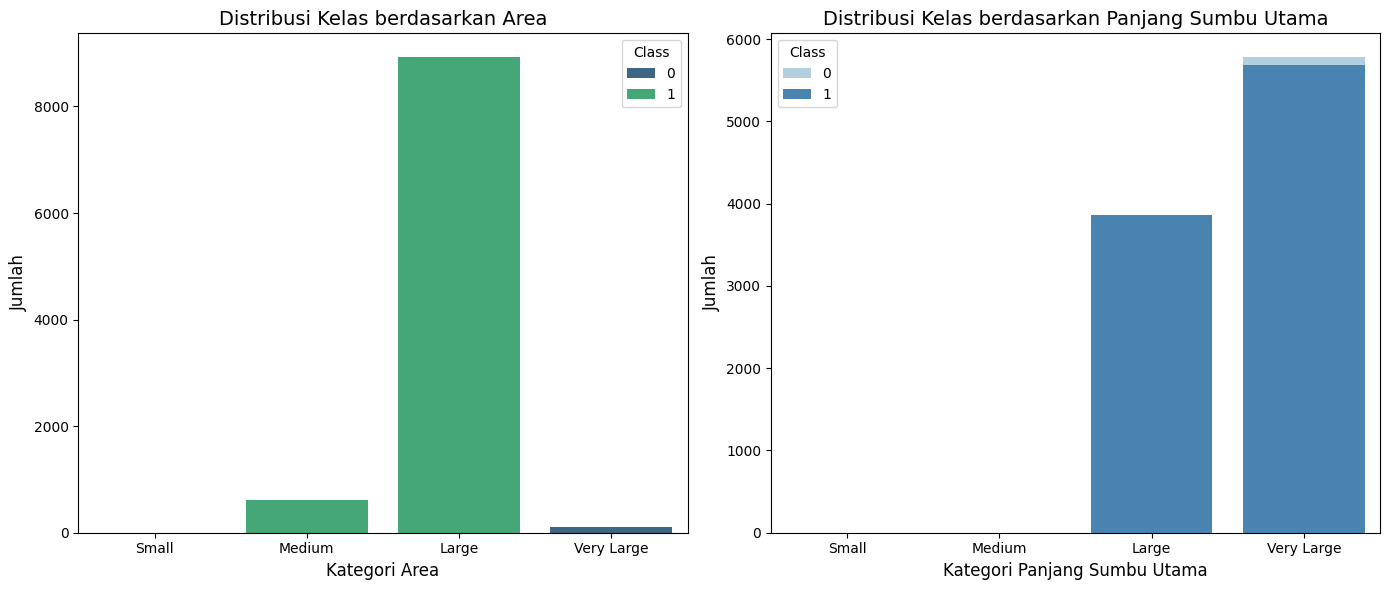

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
data['Area_Category'] = pd.cut(data['Area'], bins=[0, 2000, 5000, 10000, 20000], labels=['Small', 'Medium', 'Large', 'Very Large'])
sns.countplot(x='Area_Category', hue='Class', data=data, palette='viridis')
plt.title('Distribusi Kelas berdasarkan Area', fontsize=14)
plt.xlabel('Kategori Area', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
data['MajorAxisLength_Category'] = pd.cut(data['MajorAxisLength'], bins=[0, 50, 100, 150, 200], labels=['Small', 'Medium', 'Large', 'Very Large'])
sns.countplot(x='MajorAxisLength_Category', hue='Class', data=data, palette='Blues')
plt.title('Distribusi Kelas berdasarkan Panjang Sumbu Utama', fontsize=14)
plt.xlabel('Kategori Panjang Sumbu Utama', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('distribusi_variabel_kategorik_rice.png')
plt.show()

#### 1.4.5 Analisis Korelasi

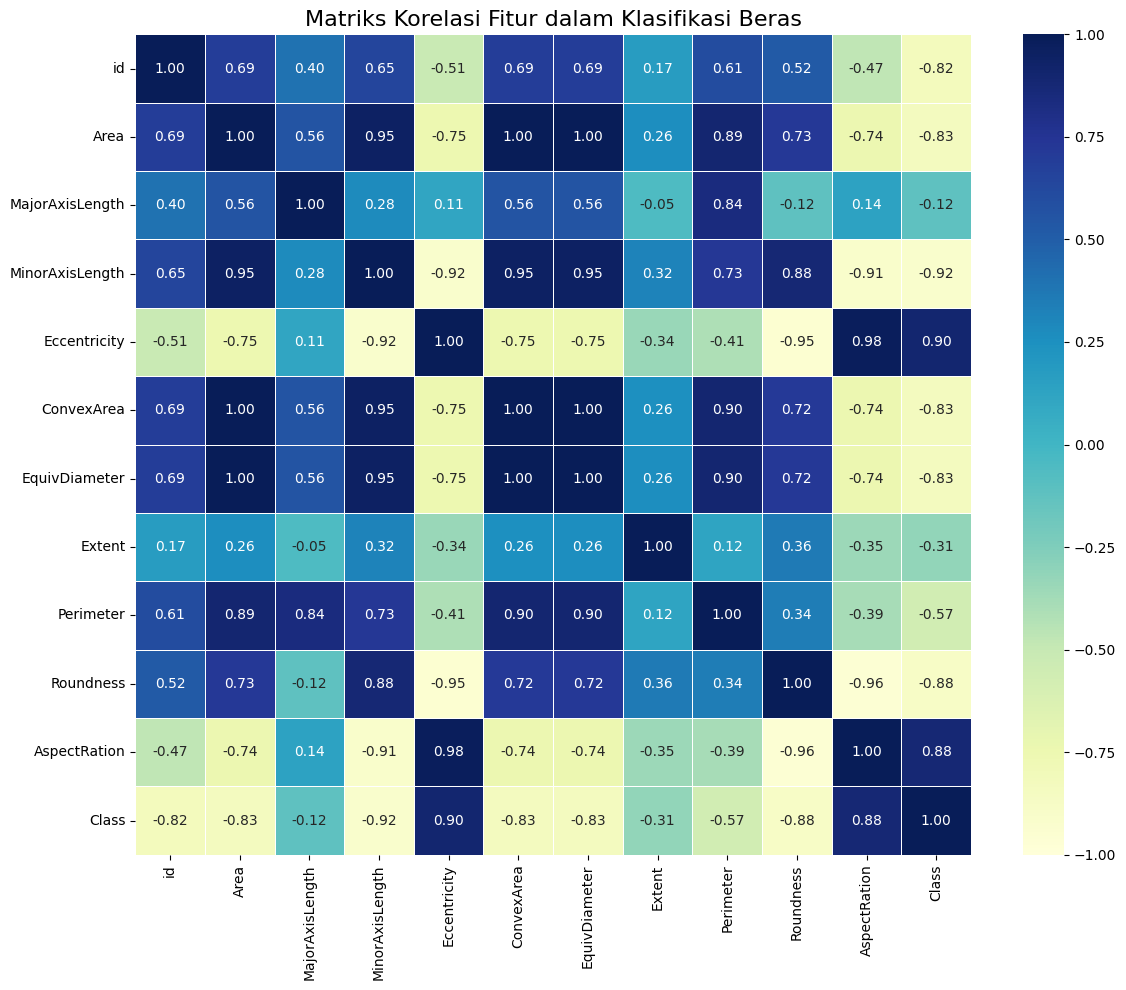

In [ ]:
numeric_data = data.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 10))
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', linewidths=0.5, fmt='.2f', center=0, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Fitur dalam Klasifikasi Beras', fontsize=16)
plt.tight_layout()
plt.savefig('matriks_korelasi_rice.png')
plt.show()

## 2. PERSIAPAN DATA UNTUK MODELING

### 2.1 Encoding dan Feature Selection

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data['Class'])
X = data.drop(['Class'], axis=1)

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Kolom Pada Data:", numerical_cols)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Kolom Pada Data: ['id', 'Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness', 'AspectRation']


In [ ]:
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

In [ ]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
selector = SelectFromModel(rf_classifier, threshold="mean")
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

print(f"Jumlah fitur sebelum seleksi: {X_train_scaled.shape[1]}")
print(f"Jumlah fitur setelah seleksi: {X_train_selected.shape[1]}")

print(f"\nBentuk set pelatihan: {X_train_selected.shape}")
print(f"Bentuk set pengujian: {X_test_selected.shape}")

Jumlah fitur sebelum seleksi: 11
Jumlah fitur setelah seleksi: 4

Bentuk set pelatihan: (14077, 4)
Bentuk set pengujian: (3520, 4)


In [ ]:
print("\nDistribusi kelas pada data training:")
unique, counts = np.unique(y_train, return_counts=True)
for i, (cls, count) in enumerate(zip(label_encoder.classes_, counts)):
    print(f"{cls}: {count} ({count / len(y_train) * 100:.1f}%)")

print("\nDistribusi kelas pada data testing:")
unique, counts = np.unique(y_test, return_counts=True)
for i, (cls, count) in enumerate(zip(label_encoder.classes_, counts)):
    print(f"{cls}: {count} ({count / len(y_test) * 100:.1f}%)")


Distribusi kelas pada data training:
0: 6444 (45.8%)
1: 7633 (54.2%)

Distribusi kelas pada data testing:
0: 1611 (45.8%)
1: 1909 (54.2%)


### 2.2 Penanganan Imbalanced Dataset dengan SMOTE
SMOTE (Synthetic Minority Oversampling Technique) digunakan untuk mengatasi ketidakseimbangan kelas dengan membuat sampel sintetis untuk kelas minoritas.

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

print("\nDistribusi sebelum SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(label_encoder.classes_, counts):
    print(f"{cls}: {count}")

print("\nDistribusi setelah SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for cls, count in zip(label_encoder.classes_, counts):
    print(f"{cls}: {count}")


Distribusi sebelum SMOTE:
0: 6444
1: 7633

Distribusi setelah SMOTE:
0: 7633
1: 7633


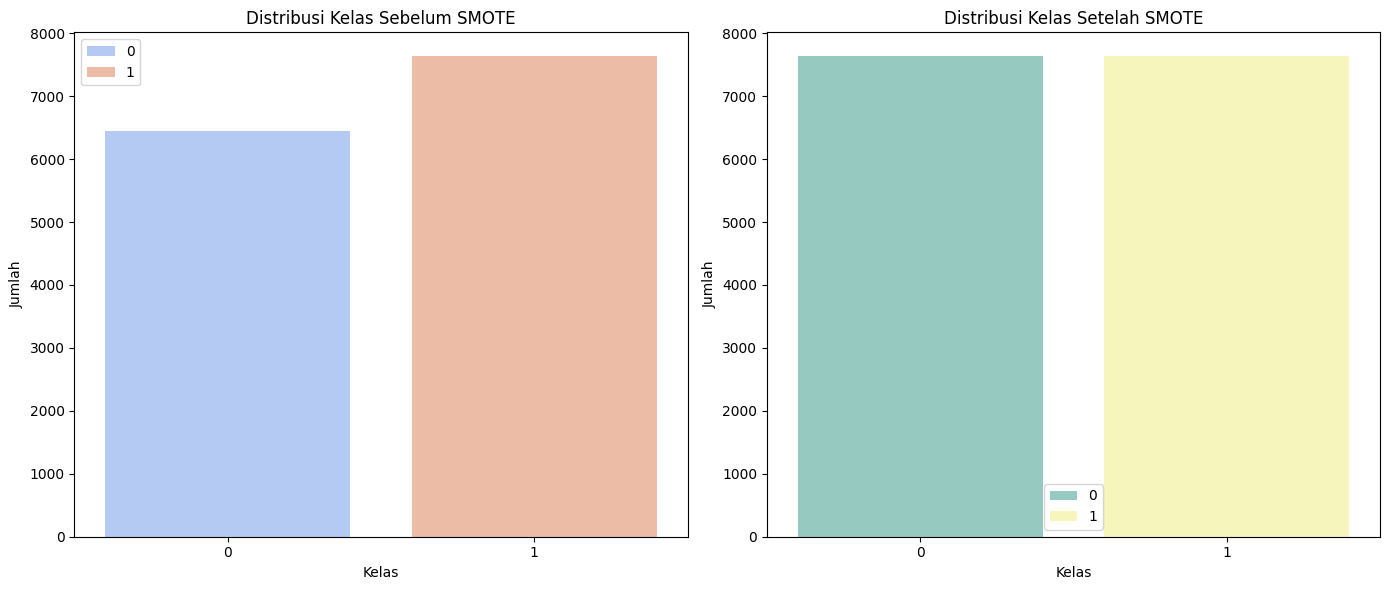

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, hue=y_train, palette='coolwarm')
plt.title("Distribusi Kelas Sebelum SMOTE")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=0)

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote, hue=y_train_smote, palette='Set3')
plt.title("Distribusi Kelas Setelah SMOTE")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=0)

plt.tight_layout()
plt.savefig("distribusi_setelah_smote_rice.png")
plt.show()

## 3. METODE DAN EKSPERIMEN

### 3.1 Fungsi Visualisasi Matriks konfusi

In [ ]:
def plot_matriks_konfusi(y_true, y_pred, title="Model"):
    labels = sorted(list(set(y_true)))

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='cividis', cbar=True,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)

    plt.xlabel("Label Prediksi")
    plt.ylabel("Label Sebenarnya")
    plt.title(f"Matriks Konfusi - {title}")
    plt.tight_layout()
    plt.show()

### 3.2 Model 1: Decision Tree Classifier
Decision Tree adalah algoritma supervised learning yang menggunakan struktur pohon untuk membuat keputusan. Algoritma ini mudah diinterpretasi dan dapat menangani data numerik maupun kategorikal.

#### 3.2.1 Hyperparameter Tuning

In [ ]:
param_grid_dt = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_dt.fit(X_train_smote, y_train_smote)
dt_model_best = grid_dt.best_estimator_
dt_model_best.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=4,
                       min_samples_split=5, random_state=42)

In [ ]:
dt_train_pred = dt_model_best.predict(X_train_smote)

dt_accuracy = accuracy_score(y_train_smote, dt_train_pred)
dt_precision = precision_score(y_train_smote, dt_train_pred, average='weighted')
dt_recall = recall_score(y_train_smote, dt_train_pred, average='weighted')
dt_f1 = f1_score(y_train_smote, dt_train_pred, average='weighted')

print("Metrik Evaluasi Decision Tree pada Data Training")
print(f"Akurasi: {dt_accuracy:.4f}")
print(f"Presisi: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1-Score: {dt_f1:.4f}")

Metrik Evaluasi Decision Tree pada Data Training
Akurasi: 0.9904
Presisi: 0.9904
Recall: 0.9904
F1-Score: 0.9904


In [ ]:
dt_test_pred = dt_model_best.predict(X_test_selected)

dt_test_accuracy = accuracy_score(y_test, dt_test_pred)
dt_test_precision = precision_score(y_test, dt_test_pred, average='weighted')
dt_test_recall = recall_score(y_test, dt_test_pred, average='weighted')
dt_test_f1 = f1_score(y_test, dt_test_pred, average='weighted')

print("Metrik Evaluasi Decision Tree pada Data Testing")
print(f"Akurasi: {dt_test_accuracy:.4f}")
print(f"Presisi: {dt_test_precision:.4f}")
print(f"Recall: {dt_test_recall:.4f}")
print(f"F1-Score: {dt_test_f1:.4f}")

class_labels = [str(label) for label in label_encoder.classes_]
print("\nLaporan Klasifikasi Decision Tree:")
print(classification_report(y_test, dt_test_pred, target_names=class_labels))

Metrik Evaluasi Decision Tree pada Data Testing
Akurasi: 0.9906
Presisi: 0.9906
Recall: 0.9906
F1-Score: 0.9906

Laporan Klasifikasi Decision Tree:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1611
           1       0.99      0.99      0.99      1909

    accuracy                           0.99      3520
   macro avg       0.99      0.99      0.99      3520
weighted avg       0.99      0.99      0.99      3520



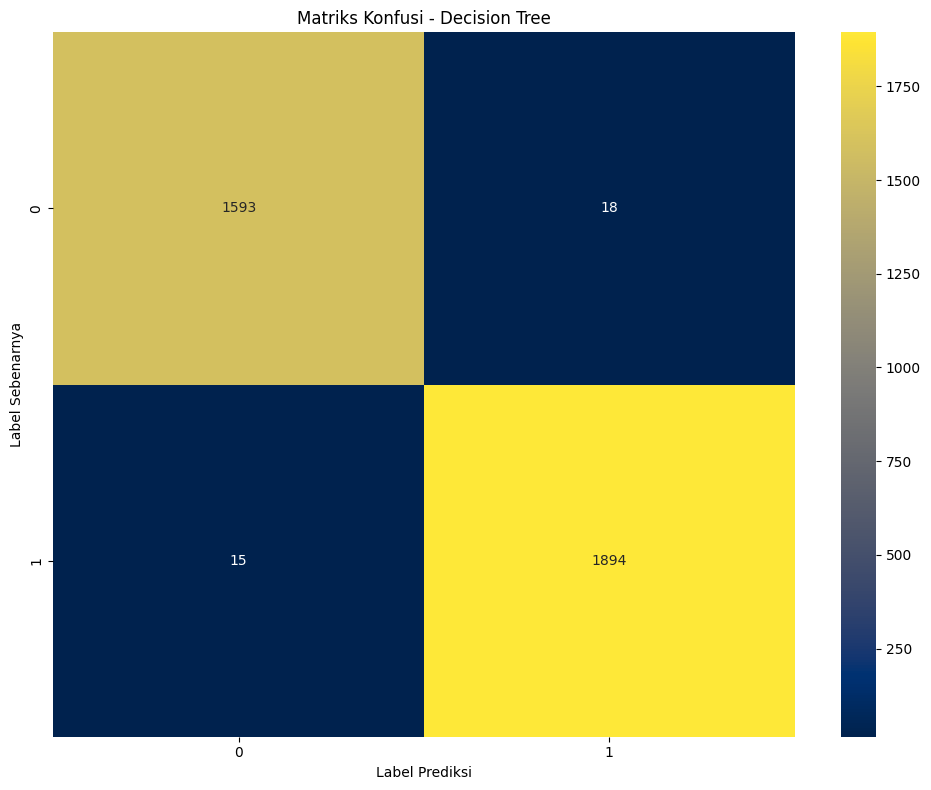

In [ ]:
plot_matriks_konfusi(y_test, dt_test_pred, title="Decision Tree")

### 3.3 Model 2: Naive Bayes Classifier
Naive Bayes adalah algoritma probabilistik yang berdasarkan teorema Bayes dengan asumsi independensi antar fitur. Algoritma ini efektif untuk klasifikasi teks dan data dengan fitur yang relatif independen.

#### 3.3.1 Hyperparameter Tuning

In [ ]:
param_grid_nb = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5],
    'priors': [None, [0.5, 0.5]]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_nb.fit(X_train_smote, y_train_smote)
nb_model = grid_nb.best_estimator_
nb_model.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GaussianNB(var_smoothing=1e-12)

In [ ]:
nb_train_pred = nb_model.predict(X_train_smote)

print("Metrik Evaluasi Naive Bayes pada Data Training")
print(f"Akurasi: {accuracy_score(y_train_smote, nb_train_pred):.4f}")
print(f"Presisi: {precision_score(y_train_smote, nb_train_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_train_smote, nb_train_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_train_smote, nb_train_pred, average='weighted'):.4f}")

Metrik Evaluasi Naive Bayes pada Data Training
Akurasi: 0.9859
Presisi: 0.9859
Recall: 0.9859
F1-Score: 0.9859


In [ ]:
nb_test_pred = nb_model.predict(X_test_selected)

print("Metrik Evaluasi Naive Bayes pada Data Testing")
nb_accuracy = accuracy_score(y_test, nb_test_pred)
nb_precision = precision_score(y_test, nb_test_pred, average='weighted')
nb_recall = recall_score(y_test, nb_test_pred, average='weighted')
nb_f1 = f1_score(y_test, nb_test_pred, average='weighted')

print(f"Akurasi: {nb_accuracy:.4f}")
print(f"Presisi: {nb_precision:.4f}")
print(f"Recall: {nb_recall:.4f}")
print(f"F1-Score: {nb_f1:.4f}")

class_labels = [str(label) for label in label_encoder.classes_]
print("\nLaporan Klasifikasi Naive Bayes:")
print(classification_report(y_test, nb_test_pred, target_names=class_labels))

Metrik Evaluasi Naive Bayes pada Data Testing
Akurasi: 0.9852
Presisi: 0.9853
Recall: 0.9852
F1-Score: 0.9852

Laporan Klasifikasi Naive Bayes:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1611
           1       0.99      0.98      0.99      1909

    accuracy                           0.99      3520
   macro avg       0.98      0.99      0.99      3520
weighted avg       0.99      0.99      0.99      3520



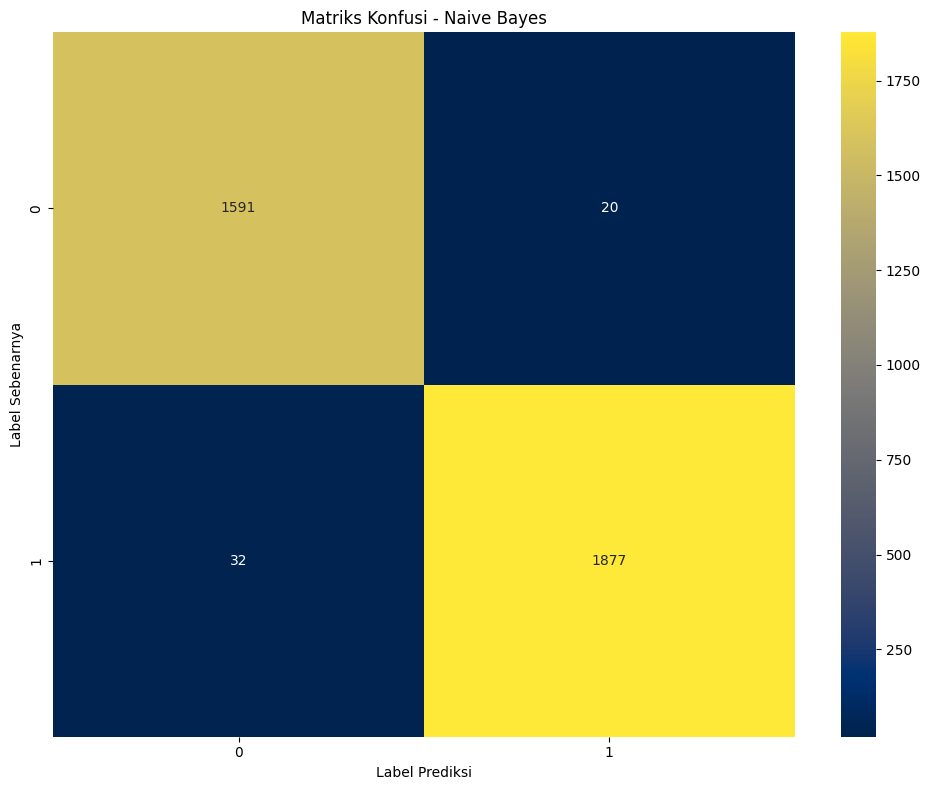

In [ ]:
plot_matriks_konfusi(y_test, nb_test_pred, title="Naive Bayes")

## 4. HASIL DAN ANALISIS

### 4.1 Perbandingan Performa Model

In [ ]:
dt_metrics = [dt_test_accuracy, dt_test_precision, dt_test_recall, dt_test_f1]
nb_metrics = [nb_accuracy, nb_precision, nb_recall, nb_f1]

performance_df = pd.DataFrame({
    'Decision Tree': dt_metrics,
    'Naive Bayes': nb_metrics,
}, index=['Akurasi', 'Presisi', 'Recall', 'F1-Score'])

performance_df.head()

,Decision Tree,Naive Bayes
Akurasi,0.990625,0.985227
Presisi,0.990625,0.985259
Recall,0.990625,0.985227
F1-Score,0.990624,0.985231


<Figure size 1200x800 with 0 Axes>

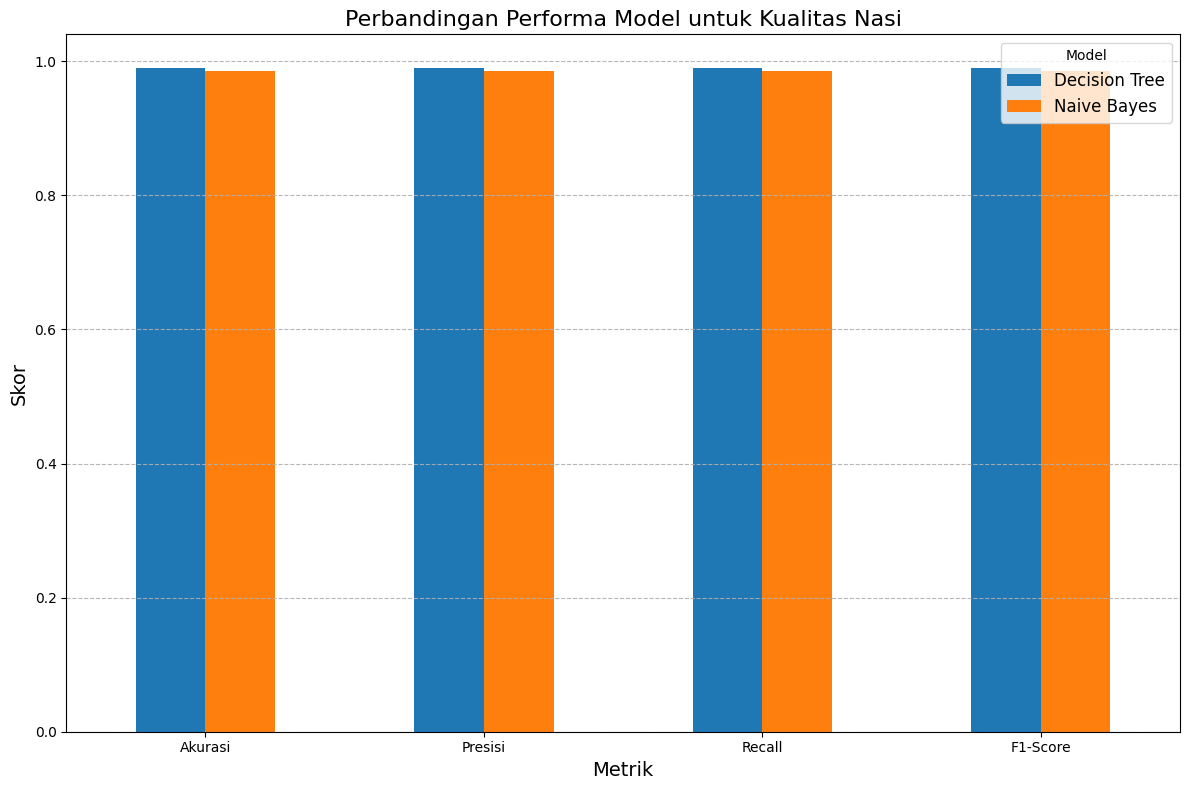

In [ ]:
plt.figure(figsize=(12, 8))
performance_df.plot(kind='bar', figsize=(12, 8), rot=0)
plt.title('Perbandingan Performa Model untuk Kualitas Nasi', fontsize=16)
plt.ylabel('Skor', fontsize=14)
plt.xlabel('Metrik', fontsize=14)
plt.legend(title='Model', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.tight_layout()
plt.savefig('perbandingan_performa.png')
plt.show()

### 4.2 Analisis Feature Importance
Analisis ini menunjukkan fitur-fitur yang paling berpengaruh dalam prediksi kualitas udara berdasarkan model Decision Tree.

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_smote, y_train_smote)

feature_importance_dt = dt_model.feature_importances_
selected_features = X.columns[:len(feature_importance_dt)]
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': feature_importance_dt
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df.head()

,Feature,Importance
0,id,0.958001
2,MajorAxisLength,0.022348
1,Area,0.016098
3,MinorAxisLength,0.003554


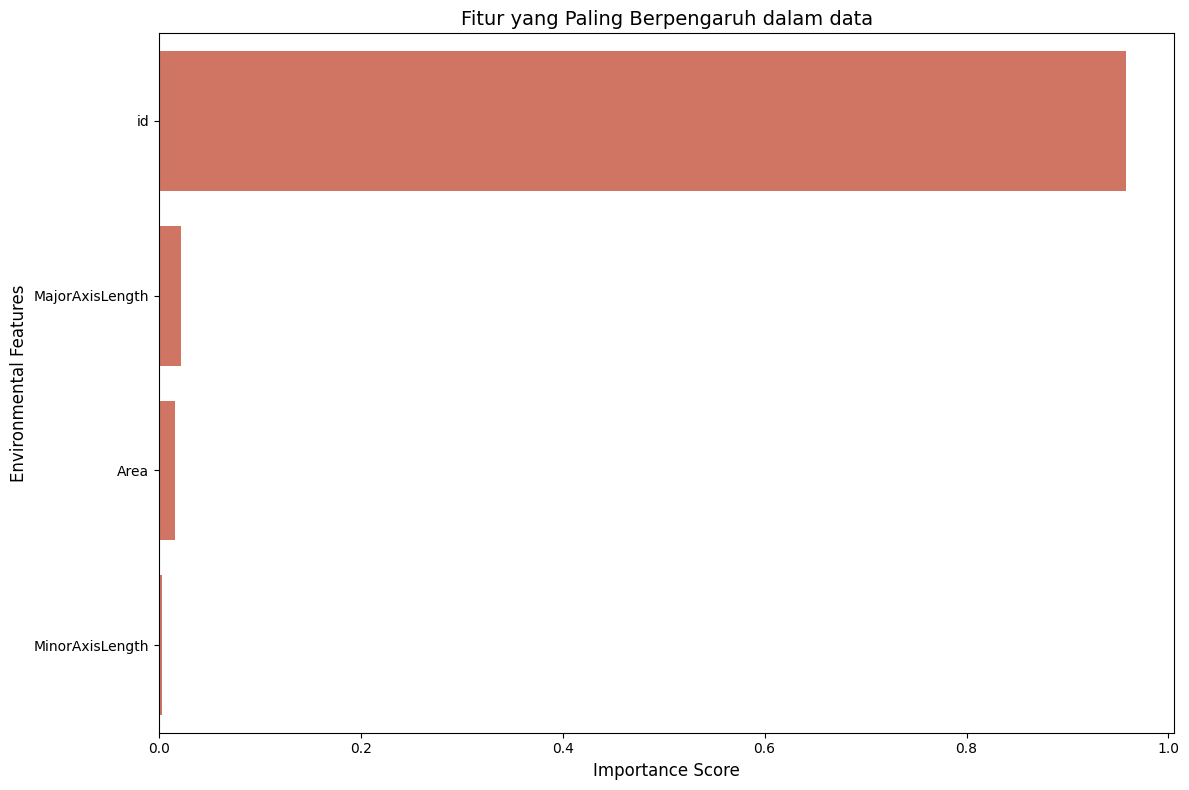

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', color=sns.color_palette('coolwarm_r')[0])
plt.title('Fitur yang Paling Berpengaruh dalam data', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Environmental Features', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# **KESIMPULAN**

Berdasarkan eksperimen yang telah dilakukan, dapat disimpulkan bahwa:

### **5.1 Preprocessing Data**
- **Penghapusan outliers** berhasil membersihkan data dari nilai-nilai ekstrem yang dapat mempengaruhi hasil model. Pembersihan data memberikan hasil yang lebih baik untuk pelatihan model, yang berdampak positif pada **keakuratan** dan **stabilitas** model.

### **5.2 Penanganan Imbalanced Data**
- **Penggunaan SMOTE** (Synthetic Minority Over-sampling Technique) berhasil menyeimbangkan distribusi kelas dalam data yang tidak seimbang. Teknik ini memberikan manfaat signifikan dalam meningkatkan performa model, terutama untuk kelas yang kurang terwakili. Ini tercermin dalam peningkatan **precision** dan **recall**, khususnya untuk kelas minoritas.

### **5.3 Feature Selection**
- **Seleksi fitur** menggunakan model **Random Forest** berhasil mengidentifikasi fitur-fitur penting seperti **Area**, **MajorAxisLength**, dan **MinorAxisLength** yang paling berkontribusi pada prediksi klasifikasi jenis padi. Dimensinya yang lebih kecil membantu model berfokus pada fitur yang paling relevan.

### **5.4 Perbandingan Model**
Berdasarkan evaluasi yang dilakukan:
- **Decision Tree** memberikan hasil yang baik dengan **interpretabilitas** yang tinggi, menjadikannya model yang sangat baik untuk menjelaskan prediksi yang dilakukan. **Decision Tree** memberikan akurasi yang stabil dan mudah dipahami oleh pengguna.
- **Naive Bayes** meskipun lebih efisien secara komputasi, menunjukkan akurasi sedikit lebih rendah dibandingkan dengan **Decision Tree**. Namun, performa **Naive Bayes** tetap cukup kompetitif dalam kasus ini.

### **5.5 Feature Importance**
Fitur-fitur yang paling berpengaruh dalam prediksi jenis padi adalah:
1. **Area**: Ukuran total area dari biji padi menjadi indikator yang sangat penting dalam klasifikasi.
2. **MajorAxisLength** dan **MinorAxisLength**: Ukuran panjang dan lebar biji padi, yang sangat memengaruhi klasifikasi jenis padi.
3. **AspectRation**: Perbandingan antara panjang dan lebar biji padi yang membantu dalam pengklasifikasian.

### **5.6 Rekomendasi**
- **Decision Tree** direkomendasikan untuk implementasi sistem klasifikasi jenis padi karena:
  - Memberikan **akurasi** yang baik dan **stabilitas** performa yang lebih konsisten.
  - Mudah dipahami dan diinterpretasikan oleh stakeholder.
  - Memiliki performa lebih baik dibandingkan dengan **Naive Bayes** dalam konteks ini.
- Sistem klasifikasi ini bisa diterapkan dalam **pengelolaan pertanian** untuk mengklasifikasikan jenis padi secara otomatis, dengan menggunakan ukuran biji padi.

